# Organize Imports and Dependencies

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import ast
import plotly.express as px
import seaborn as sns

# Data Preprocessing and Cleaning

In [2]:
# Awards Data
df_awards = pd.read_csv('df_all_award_results_v3.csv')
df_awards = df_awards.drop_duplicates() # Drop duplicates

# Transactions Data
df_transactions = pd.read_csv('df_transactions_v3.csv')

In [3]:
df_awards.info()

<class 'pandas.core.frame.DataFrame'>
Index: 311182 entries, 0 to 1335644
Data columns (total 22 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   internal_id                        311182 non-null  int64  
 1   Award ID                           311182 non-null  object 
 2   generated_internal_id              311182 non-null  object 
 3   Recipient Name                     311182 non-null  object 
 4   Recipient DUNS Number              39304 non-null   float64
 5   recipient_id                       310673 non-null  object 
 6   Award Amount                       311182 non-null  float64
 7   Awarding Agency                    311182 non-null  object 
 8   Awarding Sub Agency                311182 non-null  object 
 9   Funding Agency                     311182 non-null  object 
 10  Funding Sub Agency                 311182 non-null  object 
 11  Place of Performance City Code     0 non-nu

In [4]:
df_transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 665939 entries, 0 to 665938
Data columns (total 13 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Award ID                 665939 non-null  object 
 1   internal_id              665939 non-null  int64  
 2   generated_internal_id    665939 non-null  object 
 3   Recipient Name           665939 non-null  object 
 4   Action Date              665939 non-null  object 
 5   Award Type               665939 non-null  object 
 6   Mod                      665939 non-null  object 
 7   Transaction Amount       665939 non-null  float64
 8   Transaction Description  665769 non-null  object 
 9   Awarding Sub Agency      665939 non-null  object 
 10  Awarding Agency          665939 non-null  object 
 11  PSC                      665939 non-null  object 
 12  NAICS                    665939 non-null  object 
dtypes: float64(1), int64(1), object(11)
memory usage: 66.0+ MB


### Why are there so many more records in awards than transactions?
- There were duplicates in the data pull (around 3x). Drop duplicates using the `drop_duplicates` pandas function.

In [5]:
# The number of generated internal id's are essentially the same
print('generated_internal_id count')
print(len(df_transactions['generated_internal_id'].unique()))
print(len(df_awards['generated_internal_id'].unique()))

# Internal id functions the same way - same number of uniques
print('internal_id count')
print(len(df_transactions['internal_id'].unique()))
print(len(df_awards['internal_id'].unique()))

generated_internal_id count
311223
311182
internal_id count
311223
311182


In [6]:
print(min(df_transactions['Action Date']))
print(max(df_transactions['Action Date']))

2020-10-01
2026-04-18


### Ensure Data Types are Organized

In [7]:
# df_transactions
df_transactions['Action Date'] = pd.to_datetime(df_transactions['Action Date'])
df_transactions['Mod'] = df_transactions['Mod'].astype(str)

# df_awards
# Correct Start date of internal_id: 291499321
df_awards.loc[df_awards['internal_id'] == 291499321, 'Start Date'] = '2019-07-29'

# Correct end date of internal_id : 308227705
df_awards.loc[df_awards['internal_id'] == 308227705, 'End Date'] = '2017-04-30'

df_awards['Last Modified Date'] = pd.to_datetime(df_awards['Last Modified Date'])
df_awards['Base Obligation Date'] = pd.to_datetime(df_awards['Base Obligation Date'])
df_awards['Start Date'] = pd.to_datetime(df_awards['Start Date'])
df_awards['End Date'] = pd.to_datetime(df_awards['End Date'])

In [8]:
# Unroll PSC and NAICS Json codes into columns
df_transactions['psc_code'] = df_transactions['PSC'].apply(
    lambda x: ast.literal_eval(x).get('code') if pd.notnull(x) else None
)

df_transactions['naics_code'] = df_transactions['NAICS'].apply(
    lambda x: ast.literal_eval(x).get('code') if pd.notnull(x) else None
)

In [9]:
# Calculate aggregate statistics at parent (Award ID) level
df_t_gb = df_transactions.groupby('generated_internal_id').agg(
                                                    {'Transaction Amount' : 'sum',
                                                     'Award ID' : 'count',
                                                     'Mod' : 'count',
                                                     'psc_code': 'first',
                                                     'naics_code': 'first'}).reset_index()

In [10]:
# Merge to df_awards
df_merge = pd.merge(df_awards, df_t_gb, how = 'left', on = 'generated_internal_id')

### Create a Binary Column for Overspend

In [11]:
# Create a threshold for what classifies as overspend
overspend_threshold = 100

df_merge['overspend'] = df_merge['Transaction Amount'] > df_merge['Award Amount']
df_merge['overspend_amount'] = df_merge['Transaction Amount'] - df_merge['Award Amount'] > overspend_threshold

### Create a Binary Column for Incumbent (is_democrat)

In [12]:
# Create Democrat / Republican column
def is_democrat(date_input):
    # Biden term: Jan 20, 2021 to Jan 20, 2025
    biden_start = pd.Timestamp('2021-01-20')
    biden_end = pd.Timestamp('2025-01-20')
    
    # Check if the row's date falls within the Biden administration
    if biden_start <= pd.Timestamp(date_input) < biden_end:
        return 1
    else:
        return 0
    
df_merge['is_democrat'] = df_merge['Base Obligation Date'].apply(lambda row : is_democrat(row))

### Create Modification within 1 Year Variable

In [13]:
df_transactions['Mod'] = df_transactions['Mod'].astype(str)

# Extract base dates (Mod '0') into a lookup series
# This avoids the slow lambda transform
base_dates = (
    df_transactions[df_transactions['Mod'] == '0']
    .groupby('generated_internal_id')['Action Date']
    .min()
)

# Map base dates back to every row in the group
df_transactions['first_mod_date'] = df_transactions['generated_internal_id'].map(base_dates)

# Create the flag
# Note: We compare Mod to the string '0'
df_transactions['is_within_year'] = (
    (df_transactions['Action Date'] > df_transactions['first_mod_date']) & 
    (df_transactions['Action Date'] <= df_transactions['first_mod_date'] + pd.Timedelta(days=365)) &
    (df_transactions['Mod'] != '0')
)

# Final Aggregation
# Filtering out NaT ensures we only look at IDs that actually HAD a Mod 0
has_mod_within_year = (
    df_transactions.dropna(subset=['first_mod_date'])
    .groupby('generated_internal_id')['is_within_year']
    .any() # Returns True/False
    .astype(int) # Converts True to 1, False to 0
    .reset_index()
)

df_merge = df_merge.merge(has_mod_within_year, on='generated_internal_id', how='left')

In [14]:
# Sanity Check
has_mod_within_year['is_within_year'].value_counts()

is_within_year
0    186101
1     79856
Name: count, dtype: int64

# Feature Engineering

### Funding and Awarding Agencies Diverge Variables

In [15]:
# If Awarding Agency Not equal to funding agency
df_merge['award_not_fund_agency'] = df_merge['Awarding Agency'] != df_merge['Funding Agency']

# If Awarding Sub Agency Not equal to funding agency
df_merge['award_not_fund_sub_agency'] = df_merge['Awarding Sub Agency'] != df_merge['Funding Sub Agency']

## Create Yearly Market Share

In [16]:
# Create year level and year / company level total transactions dataframes
df_transactions['action_year'] = df_transactions['Action Date'].apply(lambda x : x.year)
tx_recipients = df_transactions.groupby(['Recipient Name', 'action_year']).agg({'Transaction Amount' : 'sum'}).reset_index()
tx_total = df_transactions.groupby(['action_year']).agg({'Transaction Amount' : 'sum'}).reset_index()

# Join and calculate market share
df_market = tx_recipients.merge(tx_total, on = 'action_year')
df_market['market_share'] = df_market['Transaction Amount_x'] / df_market['Transaction Amount_y']
df_market['action_next_year'] = df_market['action_year'] + 1 
df_market = df_market[['Recipient Name', 'action_next_year', 'market_share']]

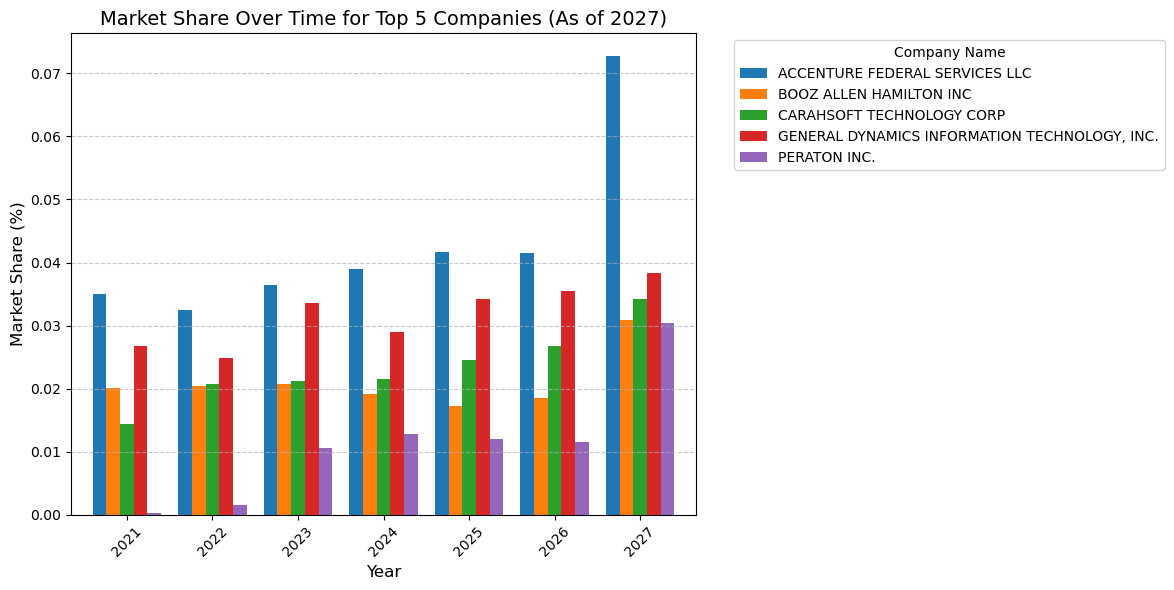

In [17]:
# Identify the most recent year in the data
most_recent_year = df_market['action_next_year'].max()

# Find the top 5 companies by market share in that specific year
# Note: Replace 'Market Share' with the actual column name from your df_market
top_5_recent_companies = (
    df_market[df_market['action_next_year'] == most_recent_year]
    .groupby('Recipient Name')['market_share']
    .sum()
    .nlargest(5)
    .index
    .tolist()
)

# 3. Filter the entire dataset to only include these 5 specific companies
df_top_cohort = df_market[df_market['Recipient Name'].isin(top_5_recent_companies)]

# 4. Aggregate market share for these companies over time
plot_data = (
    df_top_cohort.groupby(['action_next_year', 'Recipient Name'])['market_share']
    .sum()
    .unstack(fill_value=0) # Pivot: years as index, companies as columns
)

# 5. Plotting
# Use a figure size that handles the legend and labels well
fig, ax = plt.subplots(figsize=(12, 6))

# Plotting as a grouped bar chart (kind='bar' with stacked=False)
# If you prefer them stacked, change to stacked=True
plot_data.plot(kind='bar', ax=ax, width=0.8)

# Aesthetics
ax.set_title(f'Market Share Over Time for Top 5 Companies (As of {most_recent_year})', fontsize=14)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Market Share (%)', fontsize=12)
ax.legend(title='Company Name', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Save or display
plt.savefig('top_companies_market_share.png')

In [18]:
df_merge['start_year'] = df_merge['Start Date'].apply(lambda x : x.year)

# Join Market Share (from year prior) to start year of the contract
# This will lose records without transactions from the year before on left bound
df_merge = df_merge.merge(df_market, left_on = ['start_year', 'Recipient Name'], right_on = ['action_next_year', 'Recipient Name'])

In [19]:
# Save Preprocessed data to csv
df_merge.to_csv('preprocessed_award_data.csv', index = False)

In [20]:
df_merge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 247241 entries, 0 to 247240
Data columns (total 36 columns):
 #   Column                             Non-Null Count   Dtype         
---  ------                             --------------   -----         
 0   internal_id                        247241 non-null  int64         
 1   Award ID_x                         247241 non-null  object        
 2   generated_internal_id              247241 non-null  object        
 3   Recipient Name                     247241 non-null  object        
 4   Recipient DUNS Number              19814 non-null   float64       
 5   recipient_id                       246769 non-null  object        
 6   Award Amount                       247241 non-null  float64       
 7   Awarding Agency                    247241 non-null  object        
 8   Awarding Sub Agency                247241 non-null  object        
 9   Funding Agency                     247241 non-null  object        
 10  Funding Sub Agency  

### Inspect and Visualize Data Distributions

In [21]:
# Overspend comparison
fig = px.box(df_merge, x="overspend", y="Award Amount", log_y=True, title="Award Amount Distribution by Overspend Status")
fig

In [22]:
fig_tree = px.treemap(df_merge, path=['Awarding Agency', 'Awarding Sub Agency'], values='Award Amount')
fig_tree

In [23]:
state_data = df_merge.groupby('Place of Performance State Code')['Transaction Amount'].sum().reset_index()
fig = px.choropleth(state_data, locations='Place of Performance State Code', 
                    locationmode="USA-states", color='Transaction Amount', scope="usa")
fig

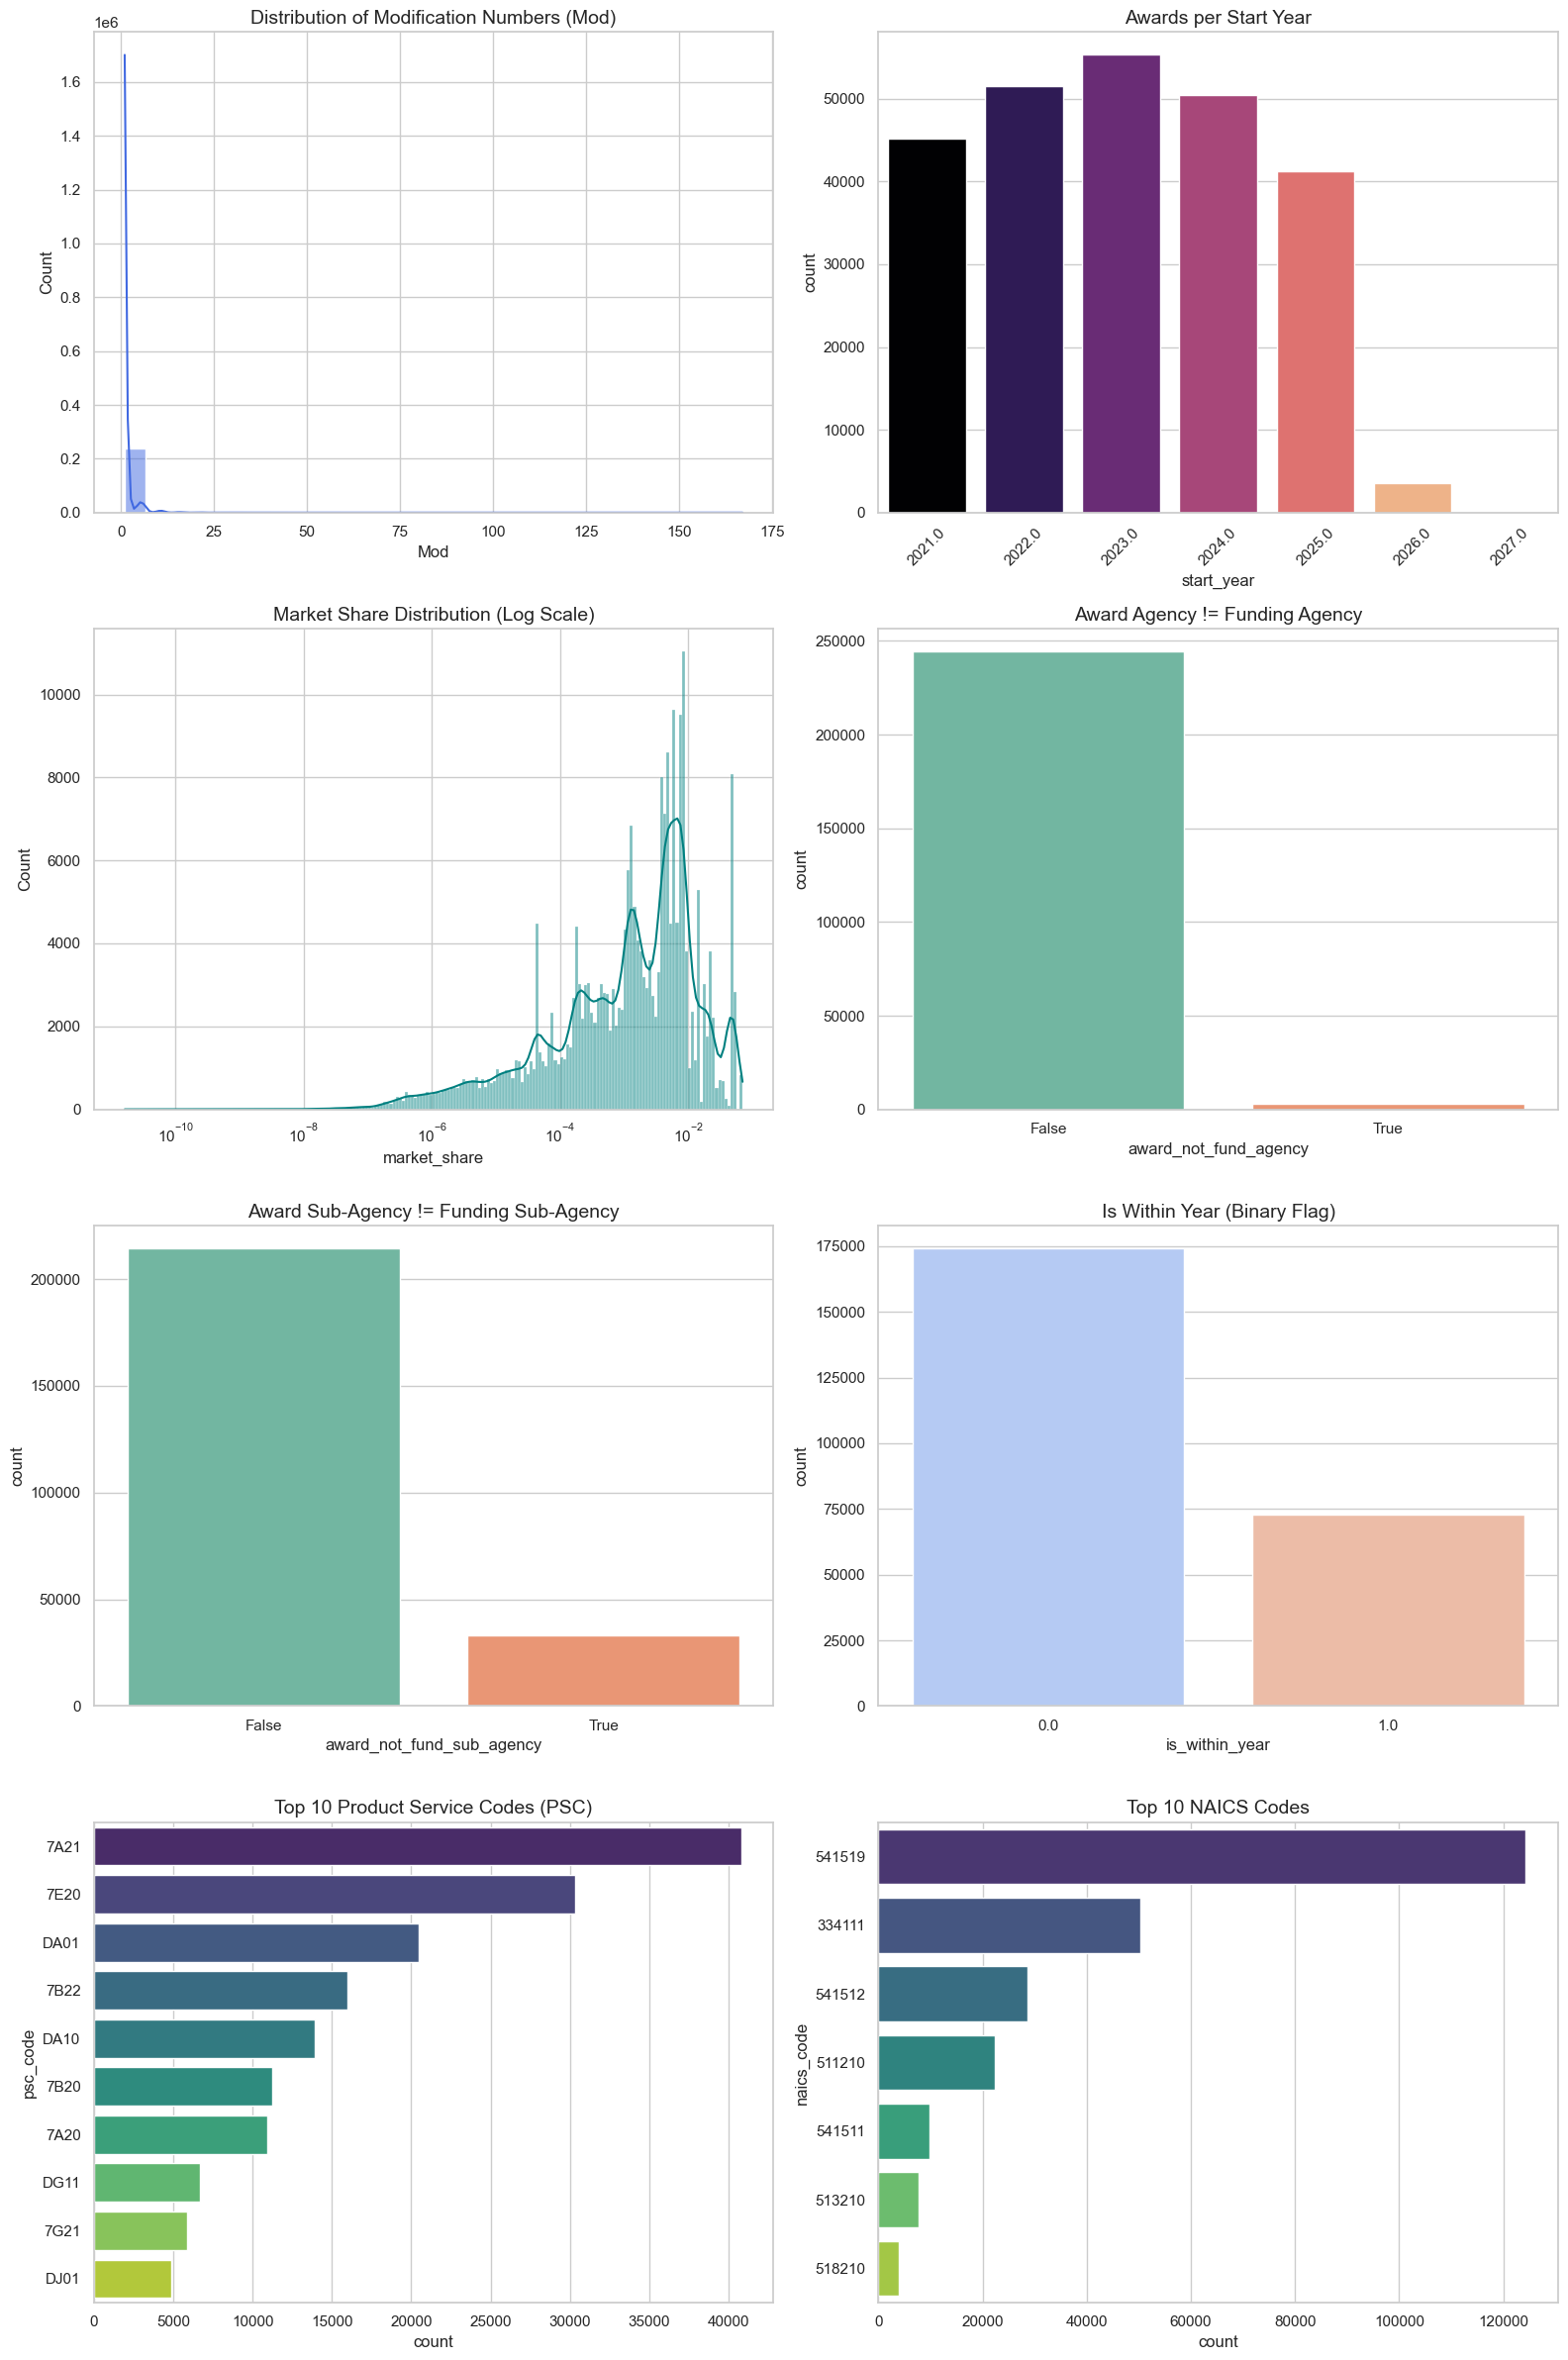

In [24]:
# Set aesthetic style
sns.set_theme(style="whitegrid")

# Create a 4x2 grid of subplots
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(16, 24))
axes = axes.flatten()

# 1. Mod (Numerical) - No hue needed for histplot
sns.histplot(df_merge['Mod'].dropna(), bins=30, kde=True, ax=axes[0], color='royalblue')
axes[0].set_title('Distribution of Modification Numbers (Mod)', fontsize=14)

# 2. start_year (Mapped x to hue)
sns.countplot(data=df_merge, x='start_year', ax=axes[1], hue='start_year', palette='magma', legend=False)
axes[1].set_title('Awards per Start Year', fontsize=14)
axes[1].tick_params(axis='x', rotation=45)

# 3. market_share (Numerical)
ms_data = df_merge[df_merge['market_share'] > 0]['market_share']
sns.histplot(ms_data, kde=True, ax=axes[2], log_scale=True, color='teal')
axes[2].set_title('Market Share Distribution (Log Scale)', fontsize=14)

# 4. award_not_fund_agency (Boolean - Mapped x to hue)
sns.countplot(data=df_merge, x='award_not_fund_agency', ax=axes[3], hue='award_not_fund_agency', palette='Set2', legend=False)
axes[3].set_title('Award Agency != Funding Agency', fontsize=14)

# 5. award_not_fund_sub_agency (Boolean - Mapped x to hue)
sns.countplot(data=df_merge, x='award_not_fund_sub_agency', ax=axes[4], hue='award_not_fund_sub_agency', palette='Set2', legend=False)
axes[4].set_title('Award Sub-Agency != Funding Sub-Agency', fontsize=14)

# 6. is_within_year (Binary - Mapped x to hue)
sns.countplot(data=df_merge, x='is_within_year', ax=axes[5], hue='is_within_year', palette='coolwarm', legend=False)
axes[5].set_title('Is Within Year (Binary Flag)', fontsize=14)

# 7. psc_code (Mapped index to hue)
top_psc = df_merge['psc_code'].value_counts().nlargest(10).reset_index()
sns.barplot(data=top_psc, x='count', y='psc_code', ax=axes[6], hue='psc_code', palette='viridis', legend=False)
axes[6].set_title('Top 10 Product Service Codes (PSC)', fontsize=14)

# 8. naics_code (Mapped index to hue)
top_naics = df_merge['naics_code'].value_counts().nlargest(10).reset_index()
sns.barplot(data=top_naics, x='count', y='naics_code', ax=axes[7], hue='naics_code', palette='viridis', legend=False)
axes[7].set_title('Top 10 NAICS Codes', fontsize=14)

plt.tight_layout()
plt.show()